# Data Warehouse — Creación e Implementación
**Materia:** Extracción de conocimiento en bases de datos  
**Maestra:** MRySI. María Reina Zarate Nava  
**Alumno:** Fernando Torres Zonahua  


## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente')
print(f'   pandas     {pd.__version__}')
print(f'   numpy      {np.__version__}')
print(f'   matplotlib {plt.matplotlib.__version__}')
print(f'   seaborn    {sns.__version__}')

Librerías importadas correctamente
   pandas     2.3.3
   numpy      2.4.6
   matplotlib 3.10.9
   seaborn    0.13.2


##  Conexión al Data Warehouse (PostgreSQL)

In [2]:
# Cadena de conexión a PostgreSQL
DB_USER     = 'postgres'
DB_PASSWORD = 'torres03'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'dw_ventas'

connection_string = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(connection_string)

# Probar la conexión
with engine.connect() as conn:
    result = conn.execute(text('SELECT version()'))
    version = result.fetchone()[0]
    print('Conexión exitosa al Data Warehouse')
    print(f'   Base de datos : {DB_NAME}')
    print(f'   Servidor      : {DB_HOST}:{DB_PORT}')
    print(f'   PostgreSQL    : {version[:40]}')

Conexión exitosa al Data Warehouse
   Base de datos : dw_ventas
   Servidor      : localhost:5432
   PostgreSQL    : PostgreSQL 15.17, compiled by Visual C++


## Creación de tablas 

In [3]:
ddl_script = """
-- Eliminar tablas si existen (orden correcto por FK)
DROP TABLE IF EXISTS fact_ventas   CASCADE;
DROP TABLE IF EXISTS dim_cliente   CASCADE;
DROP TABLE IF EXISTS dim_producto  CASCADE;
DROP TABLE IF EXISTS dim_tiempo    CASCADE;
DROP TABLE IF EXISTS dim_region    CASCADE;


-- Dimensión: Cliente
CREATE TABLE dim_cliente (
    id_cliente   SERIAL PRIMARY KEY,
    nombre       VARCHAR(100),
    email        VARCHAR(150),
    ciudad       VARCHAR(80),
    region       VARCHAR(60),
    segmento     VARCHAR(50)
);

-- Dimensión: Producto
CREATE TABLE dim_producto (
    id_producto      SERIAL PRIMARY KEY,
    nombre_producto  VARCHAR(150),
    categoria        VARCHAR(80),
    subcategoria     VARCHAR(80),
    precio_unitario  NUMERIC(10,2)
);

-- Dimensión: Tiempo
CREATE TABLE dim_tiempo (
    id_tiempo    SERIAL PRIMARY KEY,
    fecha        DATE,
    anio         INT,
    trimestre    INT,
    mes          INT,
    dia          INT,
    nombre_mes   VARCHAR(20),
    dia_semana   VARCHAR(20)
);

-- Dimensión: Región
CREATE TABLE dim_region (
    id_region      SERIAL PRIMARY KEY,
    nombre_region  VARCHAR(80),
    pais           VARCHAR(60),
    estado         VARCHAR(80),
    zona           VARCHAR(50)
);

-- Tabla de hechos: Ventas
CREATE TABLE fact_ventas (
    id_venta     SERIAL PRIMARY KEY,
    id_cliente   INT REFERENCES dim_cliente(id_cliente),
    id_producto  INT REFERENCES dim_producto(id_producto),
    id_tiempo    INT REFERENCES dim_tiempo(id_tiempo),
    id_region    INT REFERENCES dim_region(id_region),
    cantidad     INT,
    precio_venta NUMERIC(10,2),
    descuento    NUMERIC(5,2),
    monto_total  NUMERIC(12,2)
);
"""

with engine.connect() as conn:
    for stmt in ddl_script.split(';'):
        stmt = stmt.strip()
        if stmt:
            conn.execute(text(stmt))
    conn.commit()

print(' Esquema creado correctamente')
print('   Tablas: dim_cliente, dim_producto, dim_tiempo, dim_region, fact_ventas')

 Esquema creado correctamente
   Tablas: dim_cliente, dim_producto, dim_tiempo, dim_region, fact_ventas


##  Generación y carga de dimensiones

In [4]:
random.seed(42)
np.random.seed(42)

#  dim_cliente (50 registros) 
nombres = ['Ana López','Carlos Ruiz','María García','José Martínez','Laura Torres',
           'Pedro Sánchez','Rosa Hernández','Juan Ramírez','Elena Flores','Miguel Ángel Cruz',
           'Sofía Mendoza','Andrés Castillo','Gabriela Vega','Fernando Torres','Valeria Reyes',
           'Diego Morales','Patricia Guerrero','Roberto Jiménez','Carmen Delgado','Alejandro Núñez',
           'Beatriz Vargas','Sergio Ramos','Daniela Ortega','Eduardo Fuentes','Adriana Peña',
           'Marcos Silva','Claudia Aguilar','Raúl Rojas','Mónica Espinoza','Luis Cabrera',
           'Natalia Ríos','Héctor Molina','Sandra Ibarra','Óscar Domínguez','Yolanda Ponce',
           'Arturo Medina','Irene Contreras','Ernesto Lozano','Gloria Salazar','Manuel Herrera',
           'Liliana Montes','Rubén Acosta','Verónica Campos','Ignacio Blanco','Teresa Romero',
           'Álvaro Soto','Erika Luna','Ramón Gutiérrez','Pilar Navarro','Víctor Cordero']
ciudades_regiones = [
    ('Córdoba','Centro'),('Veracruz','Costa'),('Xalapa','Centro'),
    ('Orizaba','Sierra'),('Coatepec','Centro'),('Boca del Río','Costa'),
    ('Poza Rica','Norte'),('Tuxpan','Norte'),('Minatitlán','Sur'),('Coatzacoalcos','Sur')
]
segmentos = ['Premium','Regular','Premium','Regular','Corporativo']
dominios  = ['gmail.com','hotmail.com','yahoo.com','outlook.com']

clientes = []
for i, nombre in enumerate(nombres):
    ciudad, region = random.choice(ciudades_regiones)
    email = nombre.lower().replace(' ','').replace('á','a').replace('é','e')\
                  .replace('í','i').replace('ó','o').replace('ú','u')\
                  .replace('ñ','n') + f'{i}@{random.choice(dominios)}'
    clientes.append({'nombre':nombre,'email':email,'ciudad':ciudad,
                     'region':region,'segmento':random.choice(segmentos)})
df_clientes = pd.DataFrame(clientes)
df_clientes.to_sql('dim_cliente', engine, if_exists='append', index=False)
print(f' dim_cliente  → {len(df_clientes)} registros cargados')

#  dim_producto (30 registros) 
productos_data = [
    ('Laptop HP 15"','Electrónica','Computadoras',12500.00),
    ('Monitor LG 24"','Electrónica','Monitores',3800.00),
    ('Teclado Mecánico','Electrónica','Periféricos',850.00),
    ('Mouse Inalámbrico','Electrónica','Periféricos',320.00),
    ('Auriculares Sony','Electrónica','Audio',1200.00),
    ('Silla Ergonómica','Muebles','Oficina',4500.00),
    ('Escritorio L','Muebles','Oficina',6200.00),
    ('Lámpara LED','Muebles','Iluminación',450.00),
    ('Librero 5 niveles','Muebles','Almacenamiento',2100.00),
    ('Impresora Canon','Electrónica','Impresión',2800.00),
    ('Tablet Samsung','Electrónica','Tablets',5500.00),
    ('Smartphone Motorola','Electrónica','Telefonía',7200.00),
    ('Bocina Bluetooth','Electrónica','Audio',680.00),
    ('Webcam HD','Electrónica','Periféricos',950.00),
    ('Hub USB-C','Electrónica','Conectividad',420.00),
    ('Cuaderno A4 x50','Papelería','Cuadernos',85.00),
    ('Plumas (caja 12)','Papelería','Escritura',45.00),
    ('Folder Manila x25','Papelería','Archivo',95.00),
    ('Resma Papel Bond','Papelería','Papel',120.00),
    ('Grapadora Pro','Papelería','Herramientas',180.00),
    ('Mochila Laptop','Accesorios','Bolsas',650.00),
    ('Mousepad XL','Accesorios','Escritorio',210.00),
    ('Organizador cables','Accesorios','Escritorio',130.00),
    ('Soporte portátil','Accesorios','Ergonomía',380.00),
    ('Filtro privacidad','Accesorios','Pantalla',290.00),
    ('Router WiFi 6','Redes','Conectividad',1850.00),
    ('Switch 8 puertos','Redes','Conectividad',620.00),
    ('Cable HDMI 3m','Redes','Cables',95.00),
    ('Disco SSD 1TB','Electrónica','Almacenamiento',1400.00),
    ('Memoria RAM 16GB','Electrónica','Componentes',1100.00),
]
df_productos = pd.DataFrame(productos_data,
    columns=['nombre_producto','categoria','subcategoria','precio_unitario'])
df_productos.to_sql('dim_producto', engine, if_exists='append', index=False)
print(f' dim_producto → {len(df_productos)} registros cargados')

#  dim_tiempo
meses_es = {1:'Enero',2:'Febrero',3:'Marzo',4:'Abril',5:'Mayo',6:'Junio',
            7:'Julio',8:'Agosto',9:'Septiembre',10:'Octubre',11:'Noviembre',12:'Diciembre'}
dias_es  = {0:'Lunes',1:'Martes',2:'Miércoles',3:'Jueves',4:'Viernes',5:'Sábado',6:'Domingo'}
fechas   = pd.date_range('2026-01-01', periods=365)
df_tiempo = pd.DataFrame({
    'fecha'      : fechas,
    'anio'       : fechas.year,
    'trimestre'  : fechas.quarter,
    'mes'        : fechas.month,
    'dia'        : fechas.day,
    'nombre_mes' : [meses_es[m] for m in fechas.month],
    'dia_semana' : [dias_es[d] for d in fechas.dayofweek]
})
df_tiempo.to_sql('dim_tiempo', engine, if_exists='append', index=False)
print(f' dim_tiempo   → {len(df_tiempo)} registros cargados')

#  dim_region (10 regiones de Veracruz) 
regiones = [
    ('Centro','México','Veracruz','Metropolitana'),
    ('Costa','México','Veracruz','Costera'),
    ('Sierra','México','Veracruz','Montañosa'),
    ('Norte','México','Veracruz','Huasteca'),
    ('Sur','México','Veracruz','Istmo'),
    ('Capital','México','Veracruz','Gubernamental'),
    ('Olmeca','México','Veracruz','Sureste'),
    ('Totonaca','México','Veracruz','Noreste'),
    ('Sotavento','México','Veracruz','Central'),
    ('Tuxtlas','México','Veracruz','Tropical'),
]
df_region = pd.DataFrame(regiones,
    columns=['nombre_region','pais','estado','zona'])
df_region.to_sql('dim_region', engine, if_exists='append', index=False)
print(f' dim_region   → {len(df_region)} registros cargados')
print('\n Todas las dimensiones cargadas exitosamente.')

 dim_cliente  → 50 registros cargados
 dim_producto → 30 registros cargados
 dim_tiempo   → 365 registros cargados
 dim_region   → 10 registros cargados

 Todas las dimensiones cargadas exitosamente.


##  Carga de la tabla de hechos (fact_ventas)

In [5]:
# Leer IDs reales de las dimensiones
ids_clientes  = pd.read_sql('SELECT id_cliente  FROM dim_cliente',  engine)['id_cliente'].tolist()
ids_productos = pd.read_sql('SELECT id_producto FROM dim_producto', engine)['id_producto'].tolist()
ids_tiempo    = pd.read_sql('SELECT id_tiempo   FROM dim_tiempo',   engine)['id_tiempo'].tolist()
ids_region    = pd.read_sql('SELECT id_region   FROM dim_region',   engine)['id_region'].tolist()
precios_map   = pd.read_sql('SELECT id_producto, precio_unitario FROM dim_producto', engine)\
                   .set_index('id_producto')['precio_unitario'].to_dict()

# Generar 500 transacciones de venta
ventas = []
for _ in range(500):
    id_prod   = random.choice(ids_productos)
    precio    = float(precios_map[id_prod])
    cantidad  = random.randint(1, 10)
    descuento = round(random.choice([0, 0, 0, 5, 10, 15, 20]), 2)
    monto     = round(precio * cantidad * (1 - descuento / 100), 2)
    ventas.append({
        'id_cliente' : random.choice(ids_clientes),
        'id_producto': id_prod,
        'id_tiempo'  : random.choice(ids_tiempo),
        'id_region'  : random.choice(ids_region),
        'cantidad'   : cantidad,
        'precio_venta': round(precio, 2),
        'descuento'  : descuento,
        'monto_total': monto
    })

df_ventas = pd.DataFrame(ventas)
df_ventas.to_sql('fact_ventas', engine, if_exists='append', index=False)
print(f'✅ fact_ventas  → {len(df_ventas)} transacciones cargadas')
print(f'   Monto total cargado: ${df_ventas["monto_total"].sum():,.2f}')
print(f'   Rango de fechas    : 2023-01-01 al 2023-12-31')
df_ventas.head()

✅ fact_ventas  → 500 transacciones cargadas
   Monto total cargado: $4,539,918.50
   Rango de fechas    : 2023-01-01 al 2023-12-31


,id_cliente,id_producto,id_tiempo,id_region,cantidad,precio_venta,descuento,monto_total
0,5,24,273,3,8,380.0,20,2432.0
1,11,5,136,9,8,1200.0,10,8640.0
2,14,28,277,4,10,95.0,5,902.5
3,43,23,333,6,5,130.0,5,617.5
4,8,15,127,4,9,420.0,5,3591.0


## Verificación: conteo de registros por tabla

In [6]:
tablas = ['dim_cliente','dim_producto','dim_tiempo','dim_region','fact_ventas']
print('┌─────────────────────┬──────────────┐')
print('│ Tabla               │    Registros │')
print('├─────────────────────┼──────────────┤')
for tabla in tablas:
    cnt = pd.read_sql(f'SELECT COUNT(*) AS n FROM {tabla}', engine)['n'][0]
    print(f'│ {tabla:<20}│ {cnt:>12,} │')
print('└─────────────────────┴──────────────┘')

┌─────────────────────┬──────────────┐
│ Tabla               │    Registros │
├─────────────────────┼──────────────┤
│ dim_cliente         │           50 │
│ dim_producto        │           30 │
│ dim_tiempo          │          365 │
│ dim_region          │           10 │
│ fact_ventas         │          500 │
└─────────────────────┴──────────────┘


##  Consultas SQL analíticas (KPIs)

In [7]:
# KPI 1 — Ventas totales por región
df_region_kpi = pd.read_sql("""
    SELECT r.nombre_region,
           SUM(f.monto_total)   AS total_ventas,
           COUNT(f.id_venta)    AS num_transacciones,
           AVG(f.monto_total)   AS ticket_promedio
    FROM fact_ventas f
    JOIN dim_region r ON f.id_region = r.id_region
    GROUP BY r.nombre_region
    ORDER BY total_ventas DESC
""", engine)

print('═══ KPI 1: Ventas por Región ═══')
print(df_region_kpi.to_string(index=False))
print()

═══ KPI 1: Ventas por Región ═══
nombre_region  total_ventas  num_transacciones  ticket_promedio
     Totonaca     613836.75                 56     10961.370536
       Sierra     611907.50                 48     12748.072917
          Sur     523761.00                 54      9699.277778
        Costa     453463.25                 46      9857.896739
        Norte     446674.25                 56      7976.325893
      Tuxtlas     445585.25                 53      8407.268868
       Olmeca     399889.75                 56      7140.888393
      Capital     367764.00                 45      8172.533333
       Centro     340516.00                 35      9729.028571
    Sotavento     336520.75                 51      6598.446078



In [8]:
# KPI 2 — Top 10 productos más vendidos (por ingresos)
df_top_prod = pd.read_sql("""
    SELECT p.nombre_producto,
           p.categoria,
           SUM(f.cantidad)      AS unidades_vendidas,
           SUM(f.monto_total)   AS ingresos_totales
    FROM fact_ventas f
    JOIN dim_producto p ON f.id_producto = p.id_producto
    GROUP BY p.nombre_producto, p.categoria
    ORDER BY ingresos_totales DESC
    LIMIT 10
""", engine)

print('═══ KPI 2: Top 10 Productos por Ingresos ═══')
print(df_top_prod.to_string(index=False))
print()

═══ KPI 2: Top 10 Productos por Ingresos ═══
    nombre_producto   categoria  unidades_vendidas  ingresos_totales
Smartphone Motorola Electrónica                129          882000.0
      Laptop HP 15" Electrónica                 55          630000.0
     Monitor LG 24" Electrónica                124          441370.0
     Tablet Samsung Electrónica                 86          426250.0
       Escritorio L     Muebles                 70          409510.0
   Silla Ergonómica     Muebles                 68          291375.0
    Impresora Canon Electrónica                100          266420.0
      Router WiFi 6       Redes                104          181207.5
  Librero 5 niveles     Muebles                 85          165270.0
   Memoria RAM 16GB Electrónica                121          124520.0



In [9]:
# KPI 3 — Ventas mensuales (tendencia)
df_mensual = pd.read_sql("""
    SELECT t.mes,
           t.nombre_mes,
           SUM(f.monto_total)   AS total_ventas,
           COUNT(f.id_venta)    AS num_ventas
    FROM fact_ventas f
    JOIN dim_tiempo t ON f.id_tiempo = t.id_tiempo
    GROUP BY t.mes, t.nombre_mes
    ORDER BY t.mes
""", engine)

print('═══ KPI 3: Ventas Mensuales 2026 ═══')
print(df_mensual.to_string(index=False))
print()

═══ KPI 3: Ventas Mensuales 2026 ═══
 mes nombre_mes  total_ventas  num_ventas
   1      Enero     246818.75          35
   2    Febrero     599931.25          43
   3      Marzo     547352.75          40
   4      Abril     131166.25          36
   5       Mayo     453639.25          46
   6      Junio     483636.75          47
   7      Julio     390714.00          38
   8     Agosto     452864.75          53
   9 Septiembre     247156.00          32
  10    Octubre     384252.75          52
  11  Noviembre     309274.75          36
  12  Diciembre     293111.25          42



In [10]:
# KPI 4 — Ventas por categoría de producto
df_categoria = pd.read_sql("""
    SELECT p.categoria,
           SUM(f.monto_total)   AS total_ventas,
           SUM(f.cantidad)      AS unidades_totales
    FROM fact_ventas f
    JOIN dim_producto p ON f.id_producto = p.id_producto
    GROUP BY p.categoria
    ORDER BY total_ventas DESC
""", engine)

print('═══ KPI 4: Ventas por Categoría ═══')
print(df_categoria.to_string(index=False))
print()

═══ KPI 4: Ventas por Categoría ═══
  categoria  total_ventas  unidades_totales
Electrónica     3206349.0              1215
    Muebles      906025.0               318
      Redes      255043.5               313
 Accesorios      131264.0               487
  Papelería       41237.0               418



In [11]:
# KPI 5 — Ventas por segmento de cliente
df_segmento = pd.read_sql("""
    SELECT c.segmento,
           COUNT(DISTINCT c.id_cliente) AS num_clientes,
           COUNT(f.id_venta)            AS num_ventas,
           SUM(f.monto_total)           AS total_ventas,
           AVG(f.monto_total)           AS ticket_promedio
    FROM fact_ventas f
    JOIN dim_cliente c ON f.id_cliente = c.id_cliente
    GROUP BY c.segmento
    ORDER BY total_ventas DESC
""", engine)

print('═══ KPI 5: Ventas por Segmento de Cliente ═══')
print(df_segmento.to_string(index=False))

═══ KPI 5: Ventas por Segmento de Cliente ═══
   segmento  num_clientes  num_ventas  total_ventas  ticket_promedio
    Premium            23         215    1940833.00      9027.130233
Corporativo            12         140    1554637.25     11104.551786
    Regular            15         145    1044448.25      7203.091379


## Visualizaciones con Matplotlib y Seaborn

In [12]:
# Paleta 
AZUL_OSCURO  = '#1F4E79'
AZUL_MED     = '#2E75B6'
TEAL         = '#00B0A0'
AZUL_CLARO   = '#BDD7EE'
GRIS         = '#F2F2F2'
PALETTE      = [AZUL_OSCURO, AZUL_MED, TEAL, AZUL_CLARO, '#5B9BD5', '#ED7D31', '#A9D18E', '#FF0000', '#9E480E', '#636363']

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.dpi'       : 120
})
print(' Configuración de gráficos lista')

 Configuración de gráficos lista


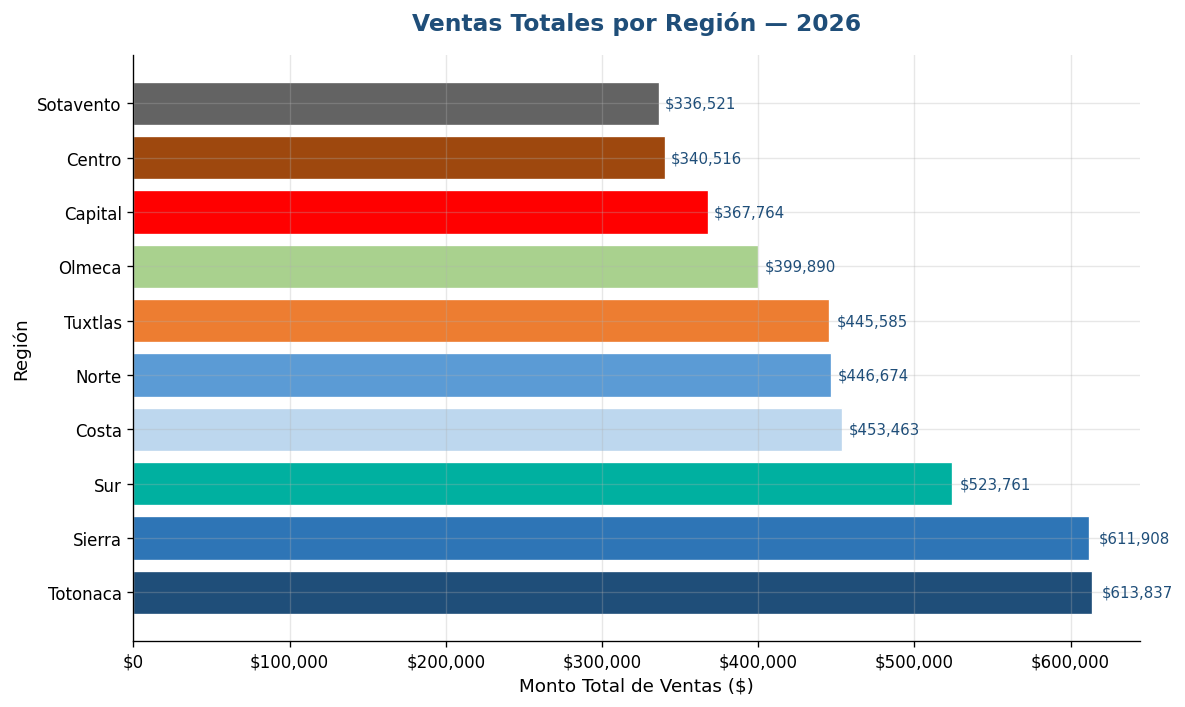

 Gráfico 1 guardado: grafico1_ventas_region.png


In [13]:
#  Gráfico 1: Barras horizontales — Ventas por Región 
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df_region_kpi['nombre_region'],
               df_region_kpi['total_ventas'],
               color=PALETTE[:len(df_region_kpi)],
               edgecolor='white', linewidth=0.8)

for bar in bars:
    w = bar.get_width()
    ax.text(w + w*0.01, bar.get_y() + bar.get_height()/2,
            f'${w:,.0f}', va='center', fontsize=9, color=AZUL_OSCURO)

ax.set_title('Ventas Totales por Región — 2026', fontsize=14, fontweight='bold', color=AZUL_OSCURO, pad=15)
ax.set_xlabel('Monto Total de Ventas ($)', fontsize=11)
ax.set_ylabel('Región', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
fig.tight_layout()
plt.savefig('grafico1_ventas_region.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Gráfico 1 guardado: grafico1_ventas_region.png')

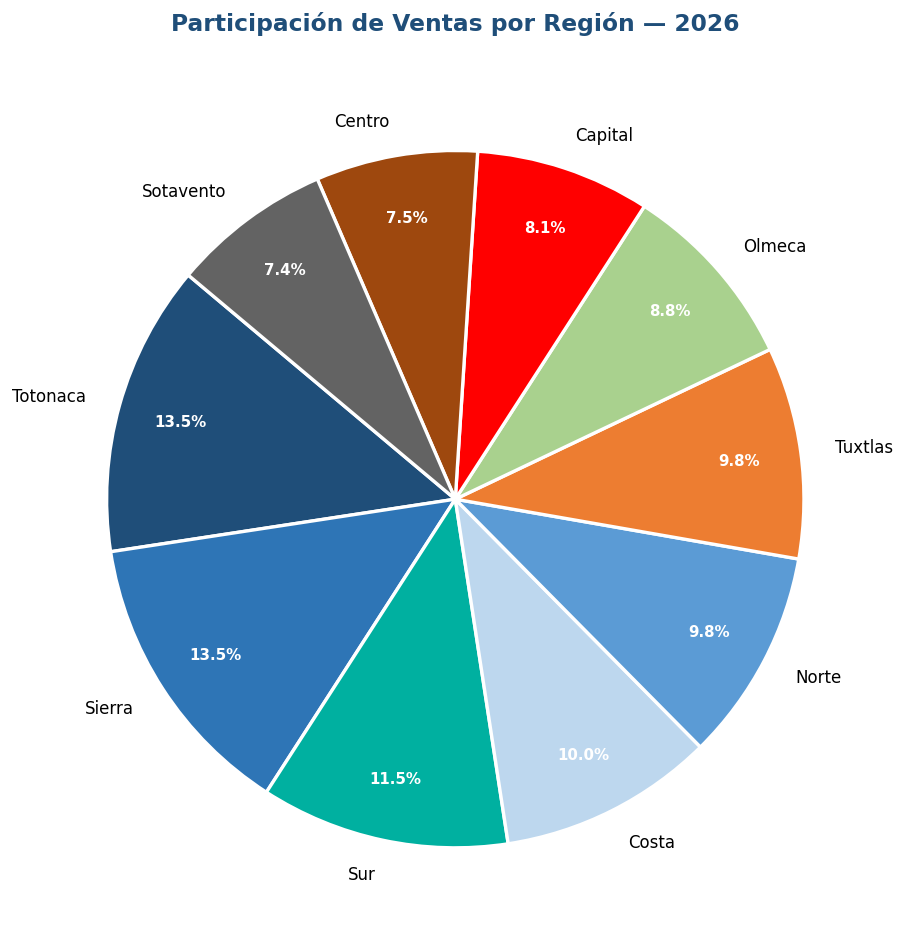

 Gráfico 2 guardado: grafico2_pastel_region.png


In [14]:
#  Gráfico 2: Pastel — Participación de ventas por Región 
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    df_region_kpi['total_ventas'],
    labels=df_region_kpi['nombre_region'],
    autopct='%1.1f%%',
    colors=PALETTE[:len(df_region_kpi)],
    startangle=140,
    pctdistance=0.82,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_color('white')
    t.set_fontweight('bold')

ax.set_title('Participación de Ventas por Región — 2026',
             fontsize=14, fontweight='bold', color=AZUL_OSCURO, pad=20)
fig.tight_layout()
plt.savefig('grafico2_pastel_region.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Gráfico 2 guardado: grafico2_pastel_region.png')

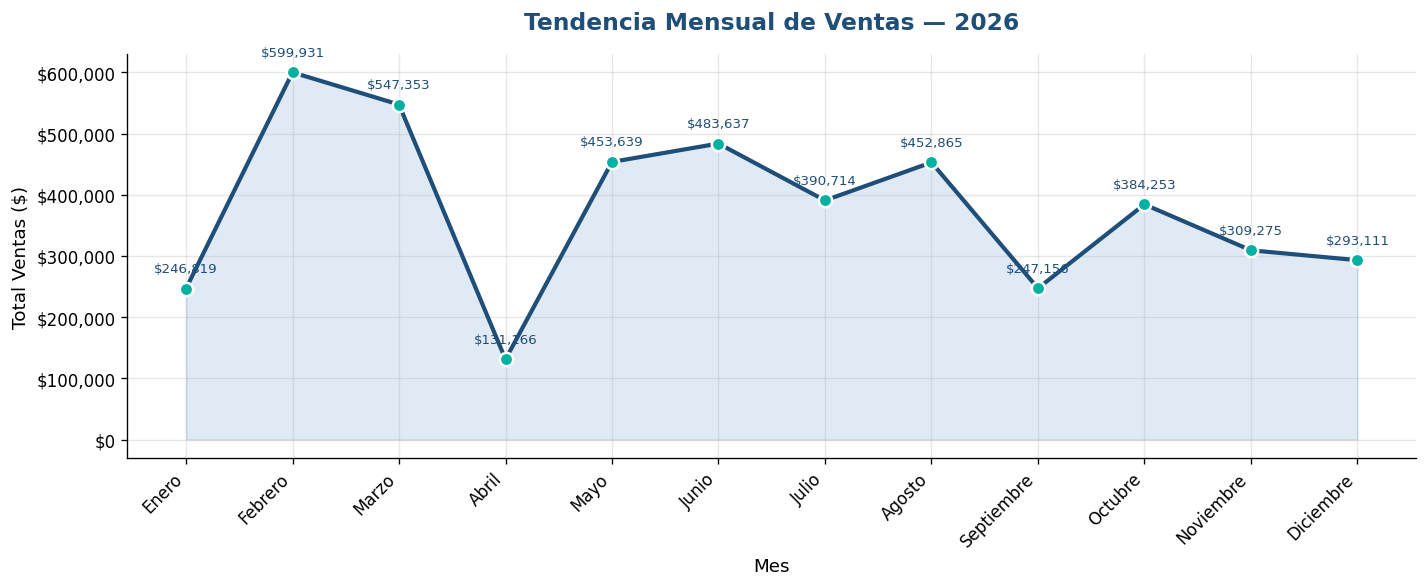

 Gráfico 3 guardado: grafico3_tendencia_mensual.png


In [15]:
#  Gráfico 3: Línea — Tendencia mensual de ventas 
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_mensual['nombre_mes'], df_mensual['total_ventas'],
        marker='o', color=AZUL_OSCURO, linewidth=2.5, markersize=8,
        markerfacecolor=TEAL, markeredgecolor='white', markeredgewidth=1.5)

ax.fill_between(range(len(df_mensual)), df_mensual['total_ventas'],
                alpha=0.15, color=AZUL_MED)

for i, (_, row) in enumerate(df_mensual.iterrows()):
    ax.annotate(f'${row.total_ventas:,.0f}',
                xy=(i, row.total_ventas),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8, color=AZUL_OSCURO)

ax.set_xticks(range(len(df_mensual)))
ax.set_xticklabels(df_mensual['nombre_mes'], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Tendencia Mensual de Ventas — 2026',
             fontsize=14, fontweight='bold', color=AZUL_OSCURO, pad=15)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Total Ventas ($)', fontsize=11)
fig.tight_layout()
plt.savefig('grafico3_tendencia_mensual.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Gráfico 3 guardado: grafico3_tendencia_mensual.png')